# Automatic Essay Scoring (AES)

**Autores:** Karolayne Teixeira da Silva e Tiago Barbosa de Lima

*Link para o respositório* [aqui](https://github.com/Tiagoblima/explanaible-essay-grading).

## Introdução
Nesta atividade, exploramos métodos de XAI aplicados para explicar a **incerteza** ou **erro** de modelos de machine learning no contexto de *Automatic Essay Scoring (AES)*. A incerteza pode surgir por variação nos dados ou limitação no conhecimento do modelo, e é essencial para entender as limitações de predição e melhorar a confiabilidade do sistema.

---

## Tema Escolhido
O tema abordado é: **"Métodos de XAI para explicação de incerteza ou erro de modelos"**. Adaptamos métodos de XAI para explicar a incerteza dos modelos construídos por meio de um modelo surrogate. 

Para isso, consideramos as incertezas:
- **Incerteza Aleatória (Aleatoric Uncertainty)**: média das incertezas de diferentes classificadores, representando variações intrínsecas dos dados.
- **Incerteza Epistêmica (Epistemic Uncertainty)**: variância das incertezas entre os modelos, refletindo a incerteza na própria modelagem.

---

## O Problema: Automatic Essay Scoring (AES)
*Automatic Essay Scoring (AES)* é uma tarefa de aprendizado de máquina que consiste em avaliar e pontuar automaticamente redações. Esse sistema pode ser usado para reduzir o tempo e custo de correções, como em avaliações de larga escala (por exemplo, o ENEM). Neste trabalho, simplificamos a tarefa para atribuir uma nota entre cinco categorias: 0, 50, 100, 150 e 200.

Para essa classificação, extraímos características como legibilidade, coesão e coerência para prever a pontuação final. Utilizamos múltiplos modelos para predizer a nota e, em seguida, calculamos a incerteza de cada modelo.

---

## 1. O Conjunto de Dados
O conjunto de dados contém redações do UOL, totalizando 4570 amostras. As notas são atribuídas de acordo com aspectos gerais do texto, e os atributos incluem métricas relacionadas à estrutura textual e à argumentação. Escolhemos utilizar a versão balanceadas dos dados para evitarmos vieses decorrente dos desbalanceamento dos dados durante a análise e investigarmos apenas o impacto relacionado a uso da features mais importantes e da modelagem do problema em si.


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
TRAIN_PATH = "../data/features/essay_train_smote.csv"
TEST_PATH = "../data/features/essay_test_scaled.csv"

train_data = pd.read_csv(TRAIN_PATH)
test_data = pd.read_csv(TEST_PATH)

train_data.head()

,adapted_dalechall,adverbs_before_main_verb_ratio,brunet_indice,clauses_per_sentence,cncadc,cncadd,cncall,cncalter,cnccaus,cnccomp,...,wrdprp1p,wrdprp1s,wrdprp2,wrdprp2p,wrdprp2s,wrdprp3p,wrdprp3s,wrdverb,yule_k,target
0,0.246978,-0.201732,-1.110548,0.202734,-1.104210,-1.233077,-1.472221,0.397606,0.175013,0.197408,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,0.895740,-0.530422,-0.549369,3
1,0.018937,-1.038710,0.705326,-0.573028,0.484122,-0.533524,-0.660713,-0.951121,-0.049625,0.424183,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,0.249079,1.064041,3
2,0.108738,-0.206416,1.087333,0.703996,-0.310044,0.865582,1.368059,1.746333,-0.498902,-0.482918,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,0.249079,-0.106775,3
3,3.308101,4.269057,-0.160047,-0.107571,-0.310044,1.040470,1.570936,1.746333,-0.049625,0.197408,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,2.067915,-0.623890,2
4,-0.661692,-0.906873,1.141768,-0.029994,-1.104210,-1.407965,-1.472221,-0.951121,-0.723540,-0.482918,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,0.881789,-0.469185,-0.530422,1.871159,1


## 2. Métodos

Para a análise de incerteza, implementamos e comparamos dois modelos: Random Forest e Regressão Logística.

- Pré-processamento dos Dados:
  - Separamos os atributos (X) e a variável alvo (Y).
  - Codificamos a incerteza de cada instância pela probabilidade máxima das previsões.

- Modelagem e Cálculo de Incerteza:
  - Incerteza Aleatória: média das incertezas entre os modelos.
  - Incerteza Epistêmica: variância das incertezas entre os modelos.

In [ ]:
feature_names = train_data.columns[:-1]
X_train = train_data.loc[:, feature_names].to_numpy()
Y_train = train_data.target.to_numpy()

X_test = test_data.loc[:, feature_names].to_numpy()
Y_test = test_data.target.to_numpy()

### 2.1. Treinamento dos Modelos 

Nesse estudo de caso, treinamos dois modelos utilizados na literatura para classificação de notas de redação, Random Forest e Logistic Regression. Os modelos foram escolhidos devido ao seu desempenho e ao fato de naturalmente terem uma saída probabilistica sem a necessidade de cálculos adicionais.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


rf_clf = RandomForestClassifier(max_depth=12, random_state=0).fit(X_train, Y_train)
lr_clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, Y_train)
clf_list = [rf_clf, lr_clf]

In [20]:
from collections import defaultdict
from sklearn import metrics

def compute_metrics(models_list, x_test, y_test, metric_dict = {
        "cohen_kappa_score": {"weights":"quadratic"}
    }):

    """
    Computa as métricas relacionadas ao smodelos retornando um dataframe pandas com o nome do 
    modelo a métrica e valor.
    models_list: list de modelos a serem avaliados
    x_test: conjunto de teste
    y_test: classes alvo 
    metric_dict: dicionário com métrica e parametros
    """

    report = defaultdict(list)
    metric_names = list(metric_dict.keys())
    for clf in models_list:
        y_hat = clf.predict(x_test)
        for metric in metric_names:
            score = getattr(metrics, metric)(y_hat, y_test, ** metric_dict[metric])
            report[clf.__class__.__name__].append(score)

    return pd.DataFrame.from_dict(report, orient='index', columns=metric_names).round(3)

In [21]:
result = compute_metrics(clf_list, X_test, Y_test)
result

,cohen_kappa_score
RandomForestClassifier,0.513
LogisticRegression,0.434


#### 2.1.1 Analise dos Resultados


Análise: Cohen Kappa

A métrica Quadratic Kappa é utilizada para avaliação de redações em diferentes trabalhos para mineração de dados educacionais [[2]](https://journals-sol.sbc.org.br/index.php/rbie/article/view/2869/2211). A métrica varia entre -1 (pior valor) e + 1 melhor valor e mede o nível de concordância entre dois anotadores em relação a uma métrica comum, nesse caso, a nota do aluno. Dessa forma, comparamos a nota fornecida por cada um dos modelos pela nota original dos anotadores. Assim, podemos concluir que o melhor modelo nesse contexto é o Random Forest que obtem um resultado de 0.513 contra 0.434 do Logistic Regression.

In [22]:
# Gerar e plotar a matriz de confusão de forma mais visual
def plot_confusion_matrix(clf, x_test, y_test):

    y_hat = clf.predict(x_test)
    conf_matrix = metrics.confusion_matrix(y_test, y_hat)

    # Plotar a matriz de confusão com heatmap
    labels = ['0', '0.5', '1', '1.5', '2']
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusão - {clf.__class__.__name__}')
    plt.show()

Análise: Matrix de Confusão

Através da matrix de confusão podemos verificar a distribuição dos acertos do modelo em relação a classe a ser predita. Nele podemos ver que o modelo tem mais facilidade em acerta classes 1 e 1.5 (com maiores exemplos) do que as classes sub-representadas como 0 e 2.

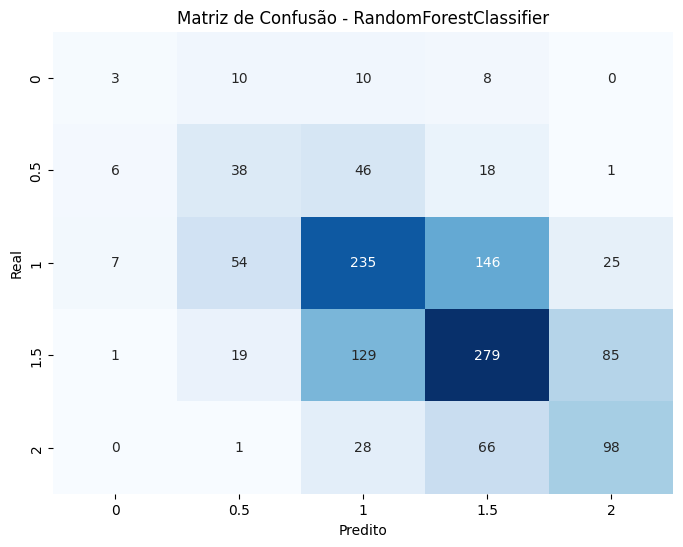

In [25]:
plot_confusion_matrix(rf_clf, X_test, Y_test)

### 2.2. Cálculo de Incertezas para cada Modelo

In [ ]:
def calculate_uncertainty(clf, x_test):
    probs = clf.predict_proba(x_test)
    max_probs = probs.max(axis=1)
    uncertainty = 1 - max_probs
    return uncertainty

In [28]:
uncertainties = {model.__class__.__name__: calculate_uncertainty(model, X_test) for model in clf_list}
uncertainty_df = pd.DataFrame(uncertainties).set_index(np.array([f"x{i}" for i in range(X_test.shape[0])]))

# Calculando Incerteza Aleatória (média) e Epistêmica (variância)
agg_uncertainty_df = uncertainty_df.agg(['mean', 'var'], axis=1).rename(columns={
    'mean': "Incerteza Aleatória",
    'var': "Incerteza Epistêmica"
})

agg_uncertainty_df.loc[:, 'Classe Real'] = Y_test
agg_uncertainty_df.sort_values(by=["Incerteza Aleatória", "Incerteza Epistêmica"]).head()


,Incerteza Aleatória,Incerteza Epistêmica,Classe Real
x993,0.185954,0.009951,3
x1195,0.192593,0.047736,4
x376,0.196241,0.040105,3
x1047,0.198434,0.042581,1
x1037,0.201157,0.060038,1


In [29]:
agg_uncertainty_df.sort_values(by=["Incerteza Aleatória", "Incerteza Epistêmica"],
 ascending=False).head()


,Incerteza Aleatória,Incerteza Epistêmica,Classe Real
x1177,0.709455,0.002013,2
x1023,0.704023,0.000081,2
x625,0.700933,0.003955,3
x745,0.692371,0.003250,2
x832,0.690347,0.000289,1


Análise: Cálculo da Incerteza 

Os dados das tabelas mostram as 5 instâncias com maior incerteza aleatória (incerteza referente a modelagem do problema e ruído dos dados) e incerteza epistêmica (incerteza relacionada ao modelo) ordenados. De acordo com a tabela, mesmo ordenando os valores relacionados a incerteza epistêmica, fica claro que há um baixo nível de incerteza relacionado ao modelo (0.002013) e um alto valor de incerteza relacionado ao problema (0.709455). Isso mostra que os modelos são treinados com dados sufientes para prover um resultado significativo de baixa incerteza e que boa parte da incerteza está relacionada a ruídos dos próprios dados. Assim sendo, uma possível solução para redução da incerteza aleatória pode ser remodelagem do problema para torná-lo mais simples. Além disso, podemos ver que as classes com maiores incertezas é a classe 2 (aluno com nota medianas entre 0.5 e 1) e maiores certezas as classes 1, 3. 

## 3. Relações entre variáveis e a incerteza aleatória
Analisamos as relações entre duas variáveis de interesse e a incerteza aleatória para entender melhor a incerteza nos dados de entrada.


#### 3.1. Histograma da Incerteza Aleatória e Epistêmica
Visualização da distribuição das incertezas aleatória e epistêmica no conjunto de dados de teste. Isso ajuda a entender a frequência e magnitude das incertezas geradas pelos modelos.

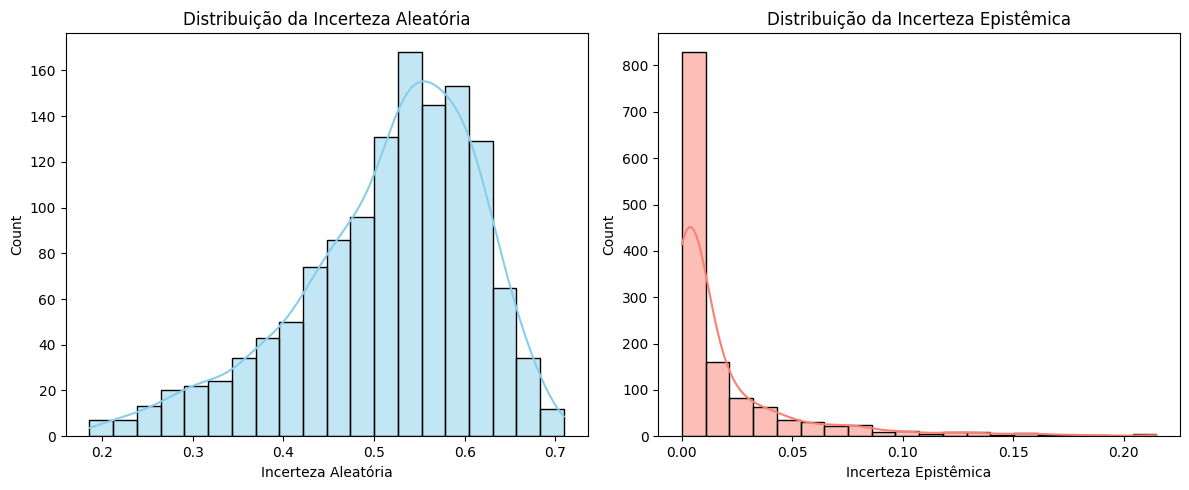

In [36]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(agg_uncertainty_df["Incerteza Aleatória"], bins=20, kde=True, color='skyblue')
plt.title("Distribuição da Incerteza Aleatória")
plt.xlabel("Incerteza Aleatória")

plt.subplot(1, 2, 2)
sns.histplot(agg_uncertainty_df["Incerteza Epistêmica"], bins=20, kde=True, color='salmon')
plt.title("Distribuição da Incerteza Epistêmica")
plt.xlabel("Incerteza Epistêmica")

plt.tight_layout()
plt.show()

Análise: Histograma

Os histogramas destacam diferenças claras entre as incertezas: a **Incerteza Aleatória** apresenta distribuição simétrica, com pico em torno de 0.5, sugerindo que os modelos têm uma confiabilidade moderada na maioria das instâncias, enquanto a **Incerteza Epistêmica** é fortemente assimétrica, com a maioria das predições concentradas em valores baixos, indicando alto consenso entre os modelos na maior parte dos casos. Contudo, a longa cauda da incerteza epistêmica revela exemplos onde os modelos divergem, possivelmente associando-se a instâncias raras ou mais difíceis. Esses padrões sugerem que os modelos capturam bem padrões gerais, mas podem precisar de melhorias para reduzir discrepâncias em casos específicos.

#### 3.2. Boxplot de Incertezas por Intervalos de Notas
Comparação das incertezas associadas a diferentes intervalos de notas (ou classes) e ver se há padrões específicos de incerteza para cada classe.

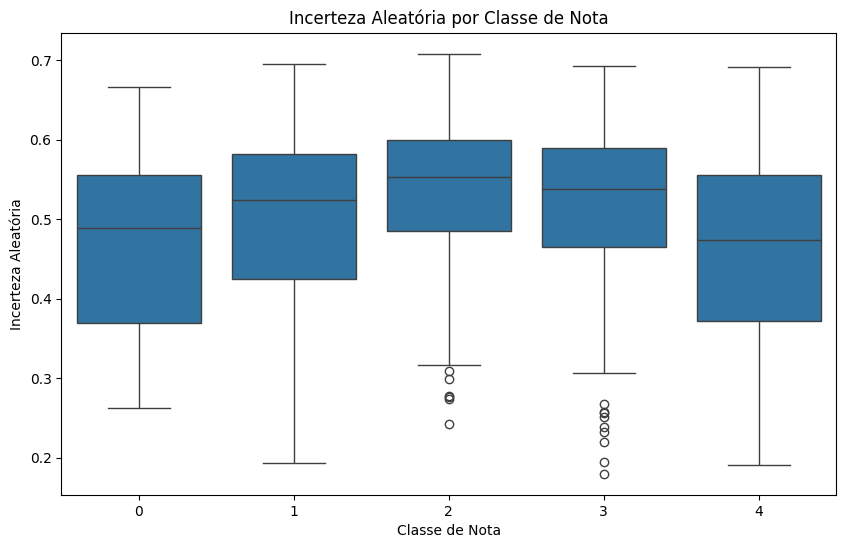

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=test_data, x="target", y=agg_uncertainty_df["Incerteza Aleatória"])
plt.title("Incerteza Aleatória por Classe de Nota")
plt.xlabel("Classe de Nota")
plt.ylabel("Incerteza Aleatória")
plt.show()


Análise: Boxplot 

Percebe-se que a **Incerteza Aleatória** é consistente entre as classes, com medianas próximas de 0.5. As classes intermediárias (2 e 3) apresentam maior número de outliers com incerteza muito baixa (abaixo de 0.3), o que indica que os modelos foram altamente confiantes em algumas instâncias. Contudo, é importante investigar se essa confiança reflete predições corretas ou casos em que os modelos podem estar excessivamente confiantes, mas errados. As classes extremas (0 e 4) mostram maior dispersão, o que pode indicar maior variabilidade nos padrões de incerteza, possivelmente devido à menor frequência ou complexidade dessas categorias nos dados.

#### 3.3. Matriz de Correlação entre Features e Incerteza
Análise da relação entre cada feature e as incertezas aleatória e epistêmica. Isso pode ajudar a identificar quais características do texto estão mais associadas a alta incerteza.

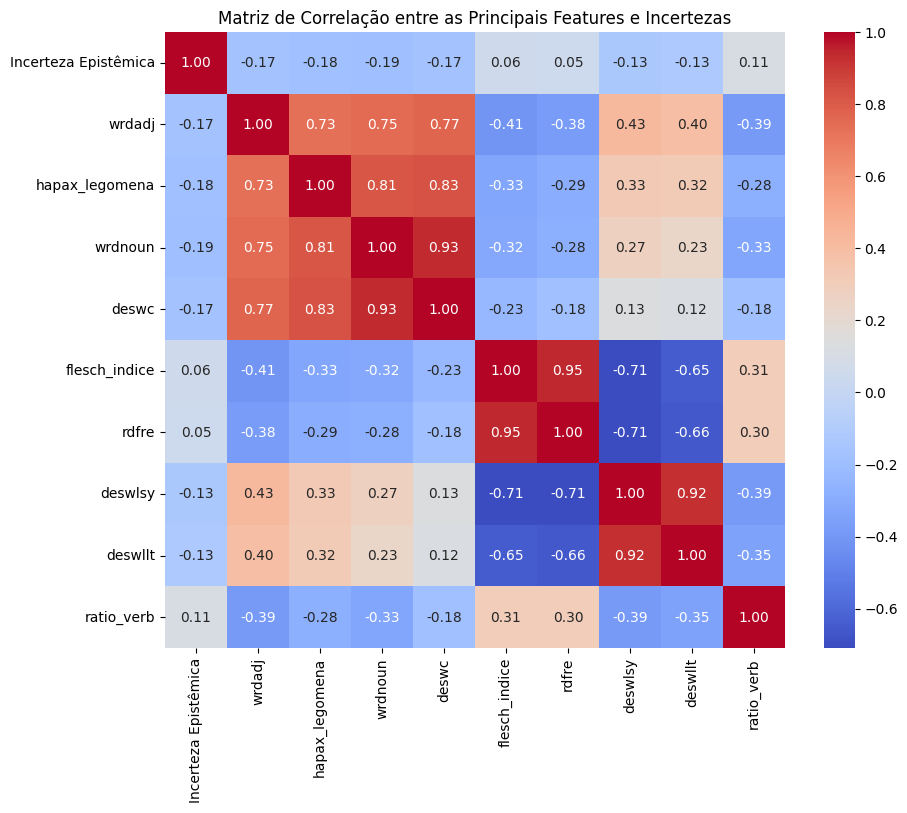

In [39]:
correlation_data = pd.concat([test_data[feature_names], agg_uncertainty_df[["Incerteza Aleatória", "Incerteza Epistêmica"]]], axis=1)
corr_matrix = correlation_data.corr()

top_k = 10 
correlations_with_uncertainty = corr_matrix["Incerteza Aleatória"].abs().sort_values(ascending=False)
top_features = correlations_with_uncertainty.index[1:top_k+1]  # Pula "Incerteza Aleatória" e seleciona as Top-K

# selected_features = ["feature1", "feature2", "feature3", ..., "Incerteza Aleatória", "Incerteza Epistêmica"]

selected_corr_matrix = corr_matrix.loc[top_features, top_features]

plt.figure(figsize=(10, 8))
sns.heatmap(selected_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação entre as Principais Features e Incertezas")
plt.show()


## 4. Importância dos Atributos no Modelo Surrogate
Usamos um modelo surrogate para prever a incerteza e identificamos os atributos que mais influenciam o modelo de incerteza.

### 4.1. Treinando um modelo surrogate com a incerteza aleatória como variável alvo

In [24]:
from sklearn.tree import DecisionTreeRegressor

In [25]:
surrogate_model = DecisionTreeRegressor()
surrogate_model.fit(X_test, agg_uncertainty_df["Incerteza Aleatória"])

DecisionTreeRegressor()

### 4.2. Importância dos Atributos no Modelo Surrogate para Predição de Incerteza

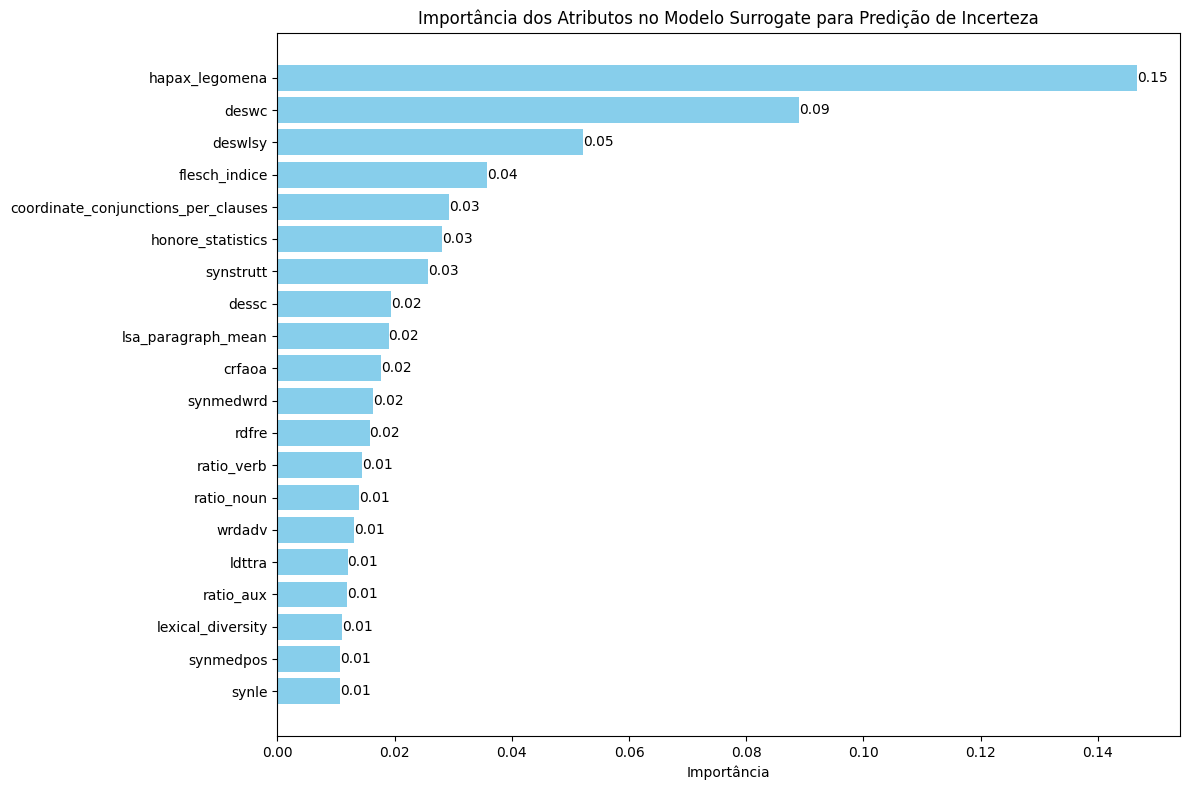

In [ ]:
limit = 20

importances = surrogate_model.feature_importances_
indices = np.argsort(importances)[::-1]  # Ordenar em ordem decrescente
sorted_features = [feature_names[i] for i in indices][:limit]
sorted_importances = importances[indices][:limit]

plt.figure(figsize=(12, 8))
plt.barh(sorted_features, sorted_importances, color="skyblue")
plt.xlabel("Importância")
plt.title("Importância dos Atributos no Modelo Surrogate para Predição de Incerteza")

for index, value in enumerate(sorted_importances):
    plt.text(value, index, f"{value:.2f}", va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Análise: Importância dos Atributos no Modelo Surrogate para Predição de Incerteza

A análise da importância dos atributos no modelo surrogate revela que **hapax_legomena** é o atributo mais relevante para prever a incerteza, com um peso significativo de 0.15. Esse atributo está associado à diversidade lexical, indicando que textos com maior singularidade lexical podem estar ligados a maiores incertezas. Outros atributos importantes incluem **deswc** (contagem de palavras) e **deswlsy** (sílabas por palavra), que refletem características estruturais do texto. A importância moderada de métricas como **flesch_indice** (legibilidade) e **honore_statistics** sugere que a complexidade linguística e a estrutura gramatical também desempenham papéis cruciais. O baixo peso relativo de outros atributos indica que esses são menos determinantes para a incerteza, embora possam contribuir em situações específicas. Essa análise destaca a influência predominante de aspectos relacionados à diversidade lexical e estrutura textual no comportamento incerto do modelo.

## 5. Relação entre Incerteza Aleatória e Principais Características


Aqui nos analisamos a relação entre as princiais características dos modelos e a incerteza ao realizar a predição. Dessa forma, poderemos concluir que valores das features causam uma maior ou menor certeza na hora de realizar a predição.

In [40]:
selected_features = ["hapax_legomena", "deswc"]
test_data.loc[:, selected_features].agg(['max', 'min'])

,hapax_legomena,deswc
max,3.466100,4.153653
min,-2.298687,-2.518159


### 5.1. Partial Dependence Plot (PDP)


Partial Dependence Plot (PDPs) nos ajudam a entender a intereção entre duas características em relação a saída. No nosso contexto, podemos analisar como as duas principais características, 'hapax_legomena' e 'deswc', na predição da classe 2 que representa as notas entre valores 800-1000.

In [46]:
SAMPLE_SIZE = 100
sample_class_4 = 6
X_sample = X_test[:SAMPLE_SIZE]
MAIN_FEATURES = ['hapax_legomena', 'deswc']
feat_idx1, feat_idx2 = np.where( np.isin(feature_names, np.array(MAIN_FEATURES)) )[0]
feat_idx1, feat_idx2

(43, 61)

Variable Importance Plot - Global Interpretation


<Figure size 640x480 with 0 Axes>

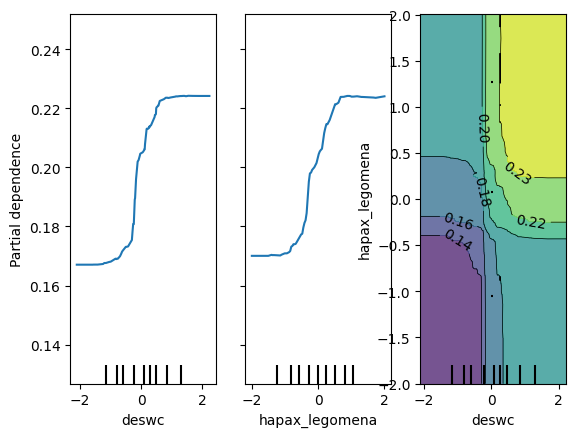

In [47]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
print("Variable Importance Plot - Global Interpretation")
figure = plt.figure()
features = [feat_idx1, feat_idx2, (feat_idx1, feat_idx2)]
PartialDependenceDisplay.from_estimator(rf_clf, X_sample,
 features, target=Y_test[sample_class_4], feature_names=feature_names)

Análise: Partial Dependece Plot 


Como definido nas celulas anteriores, estamos analisando a instância 6 que obteve uma nota entre 800-1000 (acima da média) ficando com a classe 4. A instância é interessante pelo fato do modelo prever corretamente a nota obtida o que nos ajuda na análise. 
Podemos ver, dessa forma, que duas características extraída fornecidas pelo lexicalDiversityBR e Coh-Metrix e extraídas pela biblioteca aibox-nlp se destacaram como sendo mais influentes para predição da referida classe: [*hapax_legomena*](http://fw.nilc.icmc.usp.br:23380/metrixdoc) e [*deswc*](https://link.springer.com/content/pdf/10.3758/BF03195564.pdf). A característica hapax_legomena computa o aparecemento de palavras raras usadas no texto, computando as palavras que aparecem uma única vez.  Enquanto isso a característica *deswc* avalia o uso de adverbios e adjetivos que poderiam indicam um texto mais descritivo e com mais detalhes, portanto, mais coeso. Como podemos analisar na imagem acima, quando ambas métricas tem um alto valor e isso influencia para que a nota predita também seja alto, ou seja, uma redação com alto valor de palavras raras (que aparecem uma única vez, *hapax_legomena* ) e alto valor descritivo (*deswc*) tende a ter uma nota entre os valores 800-1000.

*A descrição da característica deswc foi obitida junto ao GPTo-mini


### 5.2. Dispersão da Relação entre Incerteza Aleatória e Principais Características


In [34]:
def plot_feature_uncertainty_scatter(selected_features, agg_uncertainty_df, test_data):
    agg_uncertainty_df = agg_uncertainty_df.reset_index(drop=True)
    test_data_selected = test_data[selected_features].reset_index(drop=True)

    # Concatenar as colunas de interesse do test_data ao DataFrame de incerteza
    agg_uncertainty_df = pd.concat([agg_uncertainty_df, test_data_selected], axis=1)
    agg_uncertainty_df = agg_uncertainty_df.loc[:, ~agg_uncertainty_df.columns.duplicated()]

    print("Plotando o gráfico de dispersão com as colunas selecionadas...")
    fig, ax = plt.subplots(figsize=(12, 8))
    _ = sns.scatterplot(data=agg_uncertainty_df.dropna(), x=selected_features[0], y=selected_features[1], 
                              hue="Incerteza Aleatória", palette="viridis", alpha=0.6, s=60, ax=ax)
    ax.set_title("Dispersão das Características com Incerteza Aleatória")
    ax.set_xlabel(selected_features[0])
    ax.set_ylabel(selected_features[1])
    
    norm = plt.Normalize(agg_uncertainty_df["Incerteza Aleatória"].min(), agg_uncertainty_df["Incerteza Aleatória"].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Incerteza Aleatória")
    
    plt.show()


#### 5.2.1. Gráfico de Dispersão


Plotando o gráfico de dispersão com as colunas selecionadas...


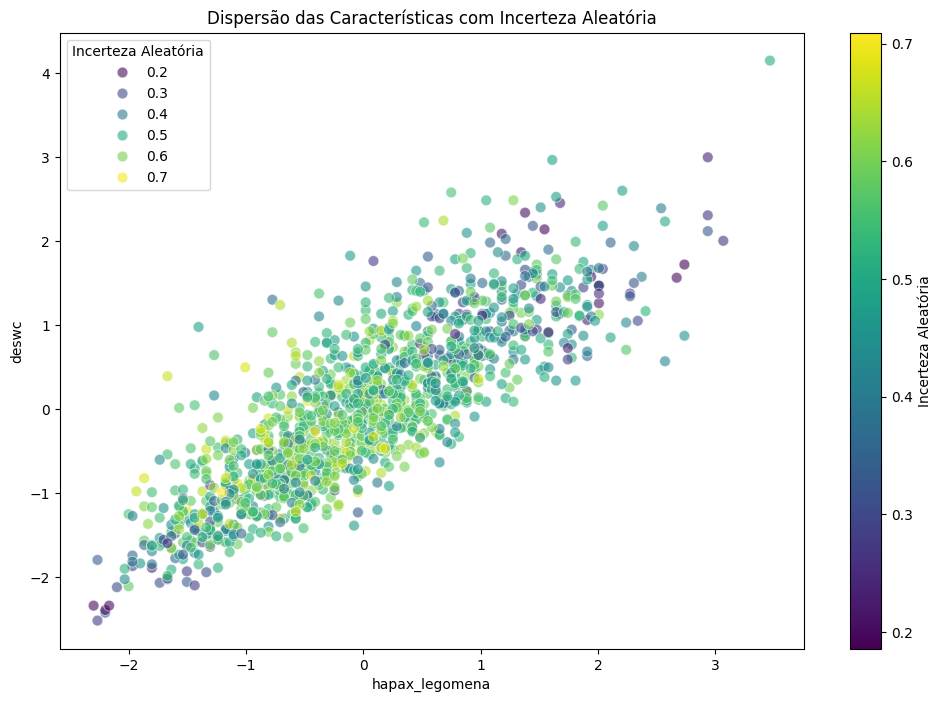

In [33]:
plot_feature_uncertainty_scatter(selected_features, agg_uncertainty_df, test_data)

Análise: Dispersão da Relação entre Incerteza Aleatória e Principais Características

Como mostrado na análise features usando o modelo sorrogate, as duas features mais importantes na classificação é hapax_legomena e a deswc que representam a diversidade lexical (calculando palavras que aparecem apenas uma vez no texto) e coesão semântica entre as sentenças respectivamente. Para ambos os casos, um valor mais alto indica uma redação com uma pontuação maior pelo fato de ter uma maior diversidade léxica e coesão textual, ao passo que se ambas tem um valor menor, elas indicam uma redação com valor menor. Como pode ser visto no gráfico acima onde o eixo x representa a features hapax_legomena e o eixo y representa a deswc. É possível ver, dessa forma, que quando ambas métricas são baixas a uma baixa incerteza e quando ambas são altas o mesmo acontece. Contudo, o cenário de incerteza muda quando os valores estão perto do centro (0), o que indica que quando as métricas são divergentes, a uma incerteza maior em relação ao resultado, ou seja, quando a redação apresenta uma boa coesão semâmtica, mas pouca diversidade lexica ou vice-versa é mais dificil para modelo decidir que nota retornar, ao passo que se ambas as métricas são altas ou são baixas e o modelo se torna mais confiante confirmando a relação de dependência parcial apresentada anteriormente. 
